In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

#BASELINE ML MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, auc, precision_recall_curve)
from sklearn.preprocessing import StandardScaler

#ADVANCED MODELS
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

#Loading Data
df= pd.read_csv("../data/processed/cdr_features.csv")

print("shape:", df.shape)
print("\nFraud Distribution:")
print(df['isFraud'].value_counts())
print("\nNull values:", df.isnull().sum().sum())
df.head()






shape: (101174, 30)

Fraud Distribution:
isFraud
False    90642
True     10532
Name: count, dtype: int64

Null values: 0


,Account Length,VMail Message,Day Mins,Day Calls,Eve Mins,Eve Calls,Night Mins,Night Calls,Intl Mins,Intl Calls,...,intl_call_ratio,intl_mins_ratio,intl_avg_duration,day_usage_ratio,night_usage_ratio,eve_usage_ratio,night_to_day_ratio,high_custserv_flag,voicemail_ratio,account_call_intensity
0,128,25,265.1,110,197.4,99,244.7,91,10.0,3,...,0.009901,0.013943,3.333333,0.369632,0.341188,0.275237,0.923048,0,0.082508,2.367187
1,107,26,161.6,123,195.5,103,254.4,103,13.7,3,...,0.009036,0.021913,4.566667,0.258477,0.406910,0.312700,1.574257,0,0.078313,3.102804
2,137,0,243.4,114,121.2,110,162.6,104,12.2,5,...,0.015015,0.022618,2.440000,0.451242,0.301446,0.224694,0.668036,0,0.000000,2.430657
3,84,0,299.4,71,61.9,88,196.9,89,6.6,7,...,0.027451,0.011686,0.942857,0.530099,0.348619,0.109596,0.657649,0,0.000000,3.035714
4,75,0,166.7,113,148.3,122,186.9,121,10.1,3,...,0.008357,0.019727,3.366667,0.325586,0.365039,0.289648,1.121176,0,0.000000,4.786667


In [10]:
#Train and Split
from sklearn.preprocessing import StandardScaler

X= df.drop(columns=['isFraud'])
Y= df['isFraud'].astype(int)

print("Features:", X.shape[1])
print("Samples:", X.shape[0])
print("\nClass Distributions:")
print(f" Legit(0): {(Y==0).sum()} ({(Y==0).mean()*100:.1f}%)")
print(f" Fraud (1): {(Y==1).sum()} ({(Y==1).mean()*100:.1f}%)")

#80% Train, 20% Test

X_train, X_test, Y_train, Y_test= train_test_split(
    X,Y,
    random_state=42,
    stratify= Y
)

print(f"\nTrain Size:{X_train.shape[0]}")
print(f" Test size: {X_test.shape[0]}")

#Logistic Regression ke liye scaling
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

print("\n Split Complete ✅")


Features: 29
Samples: 101174

Class Distributions:
 Legit(0): 90642 (89.6%)
 Fraud (1): 10532 (10.4%)

Train Size:75880
 Test size: 25294

 Split Complete ✅


MODEL 1 — LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.58      0.71     22661
           1       0.14      0.59      0.23      2633

    accuracy                           0.58     25294
   macro avg       0.53      0.58      0.47     25294
weighted avg       0.84      0.58      0.66     25294

PR-AUC Score: 0.1556


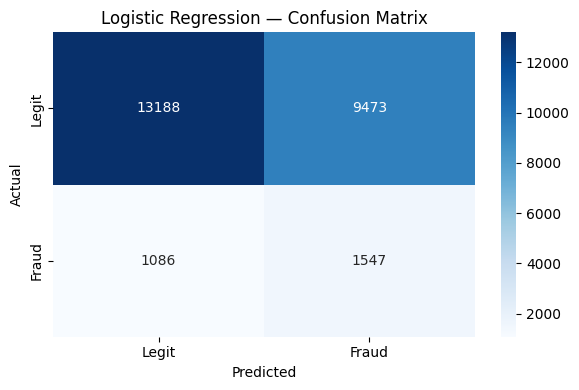


✅ Logistic Regression Done


In [13]:

# Logistic Regression


print("=" * 50)
print("MODEL 1 — LOGISTIC REGRESSION")
print("=" * 50)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  
    random_state=42
)

# Scaled data use karo LR ke liye
lr.fit(X_train_scaled, Y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_lr))

# PR-AUC
precision, recall, _ = precision_recall_curve(Y_test, y_prob_lr)
pr_auc_lr = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_lr:.4f}")

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n✅ Logistic Regression Done")

MODEL 2 — RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     22661
           1       0.77      0.85      0.81      2633

    accuracy                           0.96     25294
   macro avg       0.87      0.91      0.89     25294
weighted avg       0.96      0.96      0.96     25294

PR-AUC Score: 0.7806


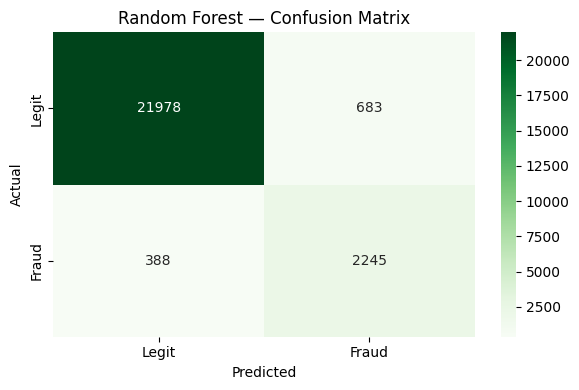


✅ Random Forest Done


In [14]:

# CELL 4 — RANDOM FOREST

print("=" * 50)
print("MODEL 2 — RANDOM FOREST")
print("=" * 50)

rf = RandomForestClassifier(
    n_estimators=100,        
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1                # saare CPU cores use karo
)

# Normal data use karo — RF ko scaling ki zaroorat nahi
rf.fit(X_train, Y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf))

# PR-AUC
precision, recall, _ = precision_recall_curve(Y_test, y_prob_rf)
pr_auc_rf = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_rf:.4f}")

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n✅ Random Forest Done")

MODEL 3 — XGBOOST
scale_pos_weight: 8.61

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     22661
           1       0.54      0.90      0.68      2633

    accuracy                           0.91     25294
   macro avg       0.77      0.91      0.81     25294
weighted avg       0.94      0.91      0.92     25294

PR-AUC Score: 0.7691


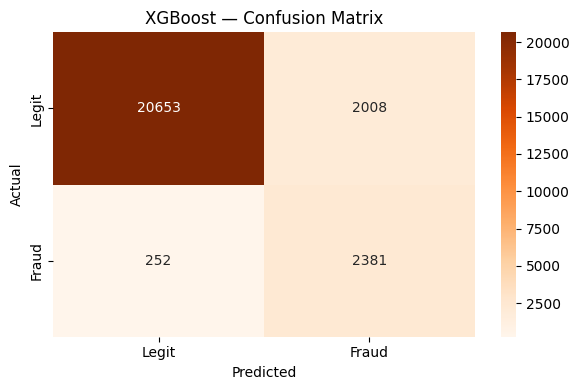


✅ XGBoost Done


In [15]:

# CELL 5 — XGBOOST

print("=" * 50)
print("MODEL 3 — XGBOOST")
print("=" * 50)

# Fraud ratio calculate karo class imbalance ke liye
scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # class imbalance handle
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',                # PR-AUC pe optimize karo
    verbosity=0                         # output clean rakho
)

xgb.fit(X_train, Y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_xgb))

# PR-AUC
precision, recall, _ = precision_recall_curve(Y_test, y_prob_xgb)
pr_auc_xgb = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_xgb:.4f}")

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n✅ XGBoost Done")

MODEL 4 — LIGHTGBM

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     22661
           1       0.46      0.90      0.60      2633

    accuracy                           0.88     25294
   macro avg       0.72      0.89      0.77     25294
weighted avg       0.93      0.88      0.89     25294

PR-AUC Score: 0.7296


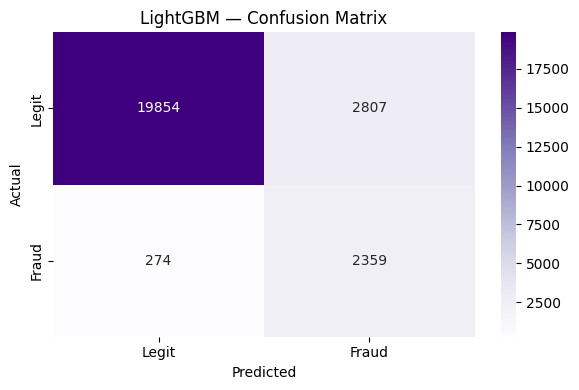


✅ LightGBM Done


In [16]:
# CELL 6 — LIGHTGBM

print("=" * 50)
print("MODEL 4 — LIGHTGBM")
print("=" * 50)

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1,
    verbose=-1                # output clean rakho
)

lgbm.fit(X_train, Y_train)
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Classification Report
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_lgbm))

# PR-AUC
precision, recall, _ = precision_recall_curve(Y_test, y_prob_lgbm)
pr_auc_lgbm = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_lgbm:.4f}")

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_lgbm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('LightGBM — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n✅ LightGBM Done")

MODEL COMPARISON TABLE
                     Precision  Recall    F1  PR_AUC
Model                                               
Logistic Regression       0.14    0.59  0.23  0.1556
Random Forest             0.77    0.85  0.81  0.7806
XGBoost                   0.54    0.90  0.68  0.7691
LightGBM                  0.46    0.90  0.60  0.7296


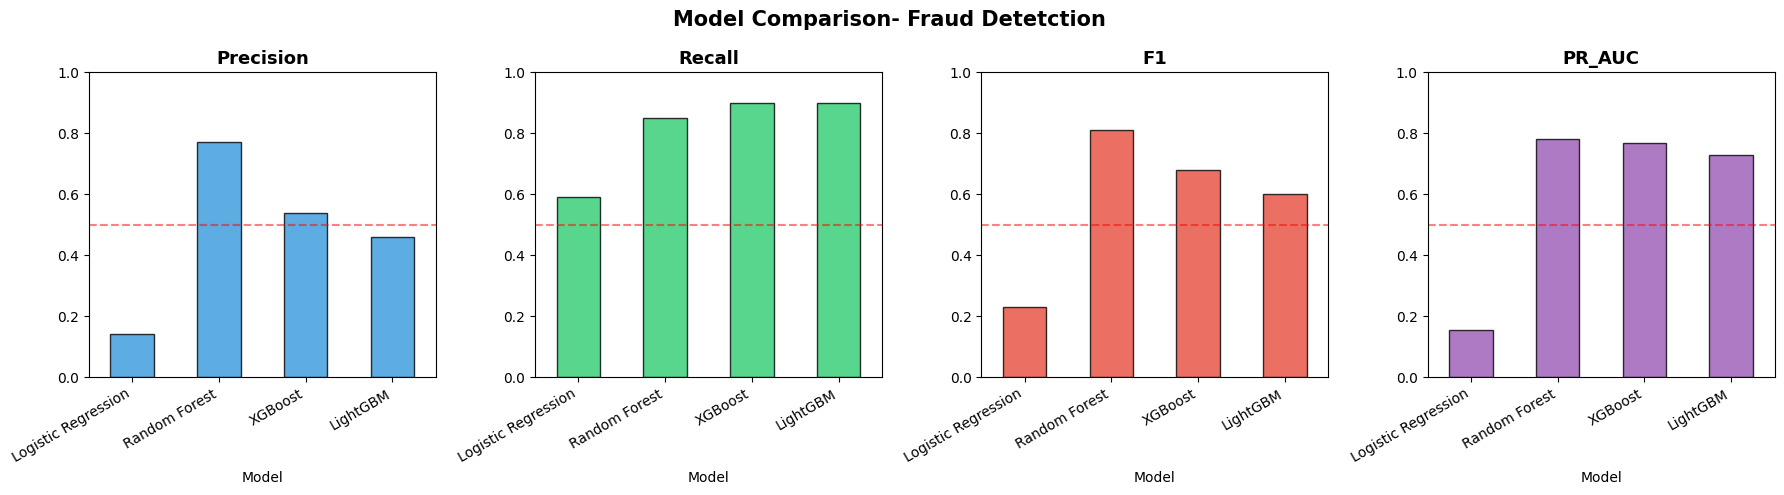


 Comparison Chart Saved!!


In [20]:
#Model Comparison Chart

results= {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Precision':[0.14, 0.77, 0.54, 0.46],
    'Recall': [0.59, 0.85, 0.90, 0.90],
    'F1': [0.23, 0.81, 0.68, 0.60],
    'PR_AUC': [0.1556, 0.7806, 0.7691, 0.7296]
}
results_df= pd.DataFrame(results)
results_df= results_df.set_index('Model')

print("=" * 50)
print("MODEL COMPARISON TABLE")
print("="* 50)
print(results_df.round(4))

#BAR CHART 

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['Precision', 'Recall', 'F1', 'PR_AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    results_df[metric].plot(
        kind='bar',
        ax=axes[i],
        color=color,       
        alpha=0.8,
        edgecolor='black'
    )
    axes[i].set_title(f'{metric}', fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df.index, rotation=30, ha='right')
    axes[i].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Model Comparison- Fraud Detetction', fontsize= 15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()

print("\n Comparison Chart Saved!!")


SHAP- RANDOM FOREST EXPLAINABILTY


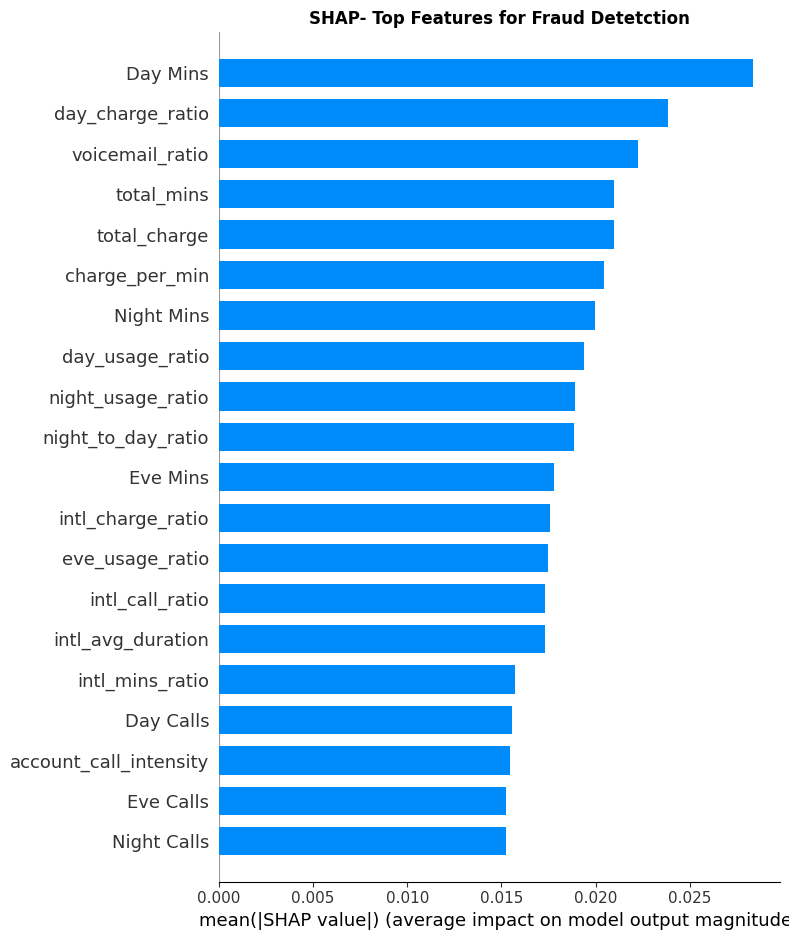

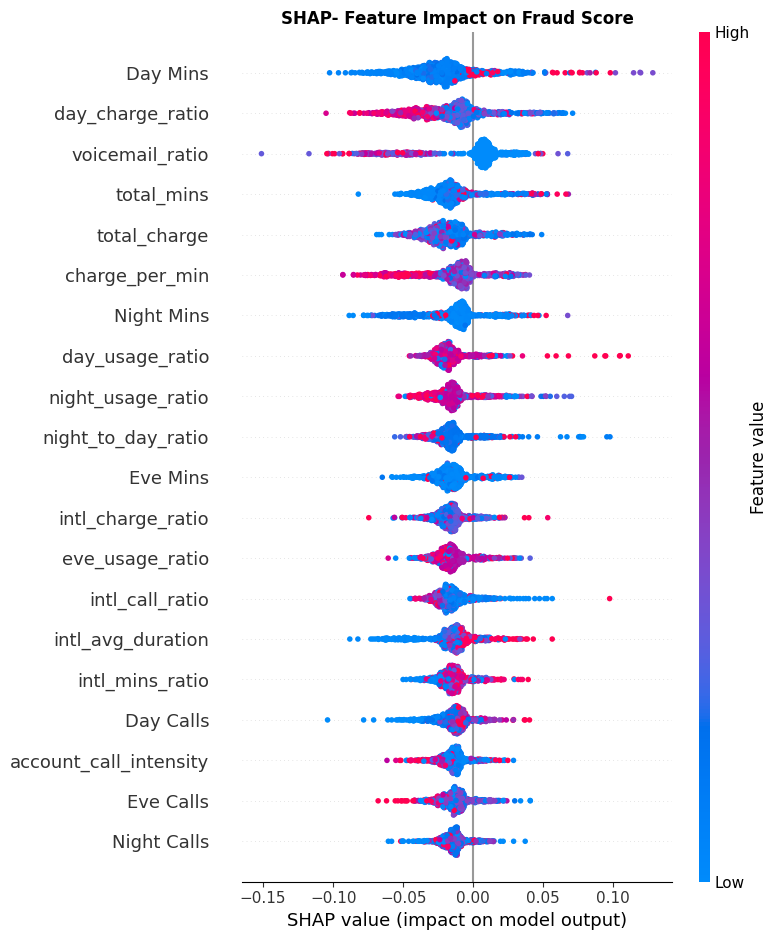


 SHAP DONE!


In [23]:
#SHAP EXPLAINABILITY

print("="*50)
print("SHAP- RANDOM FOREST EXPLAINABILTY")
print("="*50)

explainer= shap.TreeExplainer(rf)

X_sample= X_test.sample(1000, random_state=42)

shap_values= explainer.shap_values(X_sample)

#PLOT 1: Summary Plot(sabse important features)
plt.figure()
shap.summary_plot(
    shap_values[:,:,1],
    X_sample,
    plot_type="bar",
    show=False
)

plt.title("SHAP- Top Features for Fraud Detetction", fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_important.png', dpi=150)
plt.show()

#PLOT 2: Beeswarm Plot(feature impact detail)
plt.figure()
shap.summary_plot(
    shap_values[:,:,1],
    X_sample,
    show=False
)

plt.title("SHAP- Feature Impact on Fraud Score", fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150)
plt.show()

print("\n SHAP DONE!")



Model 5- Isolation Forest(Unsupervised)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     22661
           1       0.16      0.15      0.15      2633

    accuracy                           0.83     25294
   macro avg       0.53      0.53      0.53     25294
weighted avg       0.82      0.83      0.83     25294



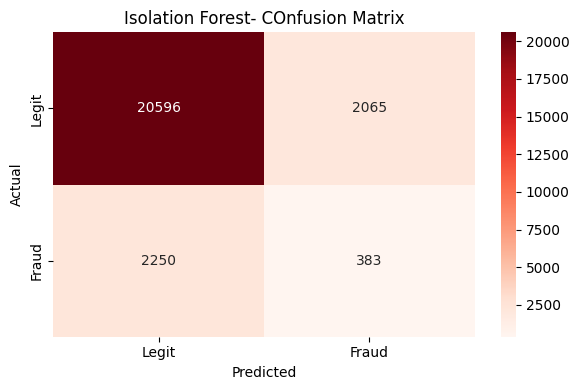


 Isolation Forest Done!


In [25]:
# ISOLATION FOREST(Unsupervised)

print("="*50)
print("Model 5- Isolation Forest(Unsupervised)")
print("="*50)

iso= IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train)

#Predict karo- -1 matlab anomaly(fraud), 1 matlab normal
y_pred_iso= iso.predict(X_test)

#Convert karo: -1 to 1(fraud), 1 to 0(legit)
y_pred_iso= (y_pred_iso == -1).astype(int)

print('\nClassification Report:')
print(classification_report(Y_test, y_pred_iso))

#Confusiin Matrix
cm= confusion_matrix(Y_test, y_pred_iso)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
        
plt.title('Isolation Forest- COnfusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n Isolation Forest Done!")

In [27]:
# SAVING BEST MODEL 

import pickle 
import os

print("="*50)
print("SAVING BEST MODEL- RANDOM FOREST CLASSIFER")
print("="*50)

os.makedirs('../models/artifacts',exist_ok=True)

with open('../models/artifacts/fraud_model.pkl','wb') as f:
    pickle.dump(rf, f)

with open('../models/artifacts/scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

#Features names save karo
features_names= X.columns.tolist()
with open('../models/artifacts/features_names.pkl','wb')as f:
    pickle.dump(features_names,f)

print("\n Saved:")
print(" -> models/artifacts/fraud_model.pkl")
print(" -> models/artifacts/scaler.pkl")
print(" -> models/artifacts/features_names.pkl")

#FINAL SUMMARY
print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Best Model : Random Forest")
print(f"Precision : 0.77 ")
print(f"Recall : 0.85")
print(f"F1 Score : 0.81")
print(f"PR-AUC : 0.7806")
print(f"Accuracy : 96%")
print(f"Total Features : {len(features_names)}")
print("="*50)




SAVING BEST MODEL- RANDOM FOREST CLASSIFER

 Saved:
 -> models/artifacts/fraud_model.pkl
 -> models/artifacts/scaler.pkl
 -> models/artifacts/features_names.pkl

FINAL MODEL SUMMARY
Best Model : Random Forest
Precision : 0.77 
Recall : 0.85
F1 Score : 0.81
PR-AUC : 0.7806
Accuracy : 96%
Total Features : 29
